# CE 1110 - Generador de señales para la defensa

Genera señales limpias y contaminadas para evaluar el **sistema distribuido de reducción adaptativa de ruido**. El notebook permite configurar casos conocidos o producir una prueba desconocida reproducible mediante una semilla. Exporta WAV de la señal limpia, el ruido y la mezcla, además de metadatos JSON y un ZIP.

> Seguridad: inicie la reproducción con volumen bajo. La salida se normaliza a un pico máximo configurable para evitar saturación digital, pero el nivel eléctrico final depende del equipo de reproducción.

In [12]:
import json, shutil, zipfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt, chirp, get_window
from IPython.display import Audio, display

plt.style.use('seaborn-v0_8-whitegrid')
print('Entorno listo')

Entorno listo


## 1. Configuración
Cambie solamente esta celda para preparar una prueba. Use `MODO = 'manual'` para fijar todos los parámetros o `MODO = 'defensa_aleatoria'` para sortear un caso reproducible.

In [13]:
CASO = 'caso_1'                 # 'caso_1', 'caso_2' o 'caso_3' (usa metadatos/configuraciones.json); None = valores de abajo
MODO = 'manual'                 # 'manual' o 'defensa_aleatoria'
SEMILLA = 3000              # guardar para reproducir exactamente la prueba
NOMBRE_PRUEBA = 'Caso_3'                # nombre de la carpeta de salida
FS = 16_000                     # Hz
DURACION = 6.0                  # s
PICO_MAXIMO = 0.80              # amplitud digital final
FADE_MS = 20                    # entrada/salida suave

# Señal útil: 'tono', 'multitono', 'chirp', 'armonicos' o 'transitoria'
TIPO_SENAL = 'multitono'
FRECUENCIAS_UTILES = [440, 880, 1320]
AMPLITUDES_UTILES = [1.0, 0.55, 0.30]
FASES_UTILES_GRADOS = [0, 35, -50]

# Ruido: 'tonal', 'red_60hz', 'blanco', 'banda', 'impulsivo' o 'mixto'
TIPO_RUIDO = 'banda'
SNR_OBJETIVO_DB = 0.0     # Alto para ver pico alejado
FRECUENCIA_INTERFERENCIA = 1750  # Hz, para tonal o mixto
BANDA_RUIDO = (600, 1500)       # Solapa frecuencias
NUM_IMPULSOS = 10

# Con CASO definido, los parámetros se leen de metadatos/configuraciones.json y las salidas
# van a su lugar: WAV en pruebas/<caso>/, muestras y figura en resultados/
RUTA_CONFIG = Path('metadatos/configuraciones.json')
if CASO is not None:
    cfg = json.loads(RUTA_CONFIG.read_text(encoding='utf-8'))[CASO]
    MODO, SEMILLA, NOMBRE_PRUEBA = cfg['modo'], cfg['semilla'], cfg['nombre_prueba']
    FS, DURACION, PICO_MAXIMO = cfg['fs_Hz'], cfg['duracion_s'], cfg['pico_maximo']
    TIPO_SENAL, FRECUENCIAS_UTILES = cfg['tipo_senal'], cfg['frecuencias_utiles_Hz']
    AMPLITUDES_UTILES, FASES_UTILES_GRADOS = cfg['amplitudes_utiles'], cfg['fases_grados']
    TIPO_RUIDO, SNR_OBJETIVO_DB = cfg['tipo_ruido'], cfg['snr_objetivo_dB']
    FRECUENCIA_INTERFERENCIA, BANDA_RUIDO = cfg['frecuencia_interferencia_Hz'], tuple(cfg['banda_ruido_Hz'])
    NUM_IMPULSOS = cfg['numero_impulsos']
    CARPETA_SALIDA = Path('pruebas')/CASO
else:
    CARPETA_SALIDA = Path('/kaggle/working/tonos_defensa') if Path('/kaggle/working').exists() else Path('tonos_defensa')
CARPETA_SALIDA

PosixPath('pruebas/caso_1')

## 2. Funciones de generación y medición

In [14]:
def rms(x):
    return float(np.sqrt(np.mean(np.square(x, dtype=np.float64))))

def snr_db(clean, observed):
    error = observed - clean
    return 10*np.log10((np.sum(clean**2)+1e-15)/(np.sum(error**2)+1e-15))

def fade(x, fs, ms=20):
    n = min(int(fs*ms/1000), len(x)//2)
    if n > 0:
        ramp = np.sin(np.linspace(0, np.pi/2, n))**2
        x = x.copy(); x[:n] *= ramp; x[-n:] *= ramp[::-1]
    return x

def normalizar_conjunto(*signals, peak=0.8):
    maximum = max(np.max(np.abs(x)) for x in signals)
    gain = peak/maximum if maximum > 0 else 1.0
    return [x*gain for x in signals], gain

def generar_limpia(kind, t, freqs, amps, phases_deg, rng):
    if kind == 'tono':
        return amps[0]*np.sin(2*np.pi*freqs[0]*t + np.deg2rad(phases_deg[0]))
    if kind == 'multitono':
        return sum(a*np.sin(2*np.pi*f*t + np.deg2rad(p)) for f,a,p in zip(freqs,amps,phases_deg))
    if kind == 'chirp':
        return chirp(t, f0=freqs[0], f1=freqs[-1], t1=t[-1], method='linear')
    if kind == 'armonicos':
        f0 = freqs[0]
        return sum((1/k)*np.sin(2*np.pi*k*f0*t + rng.uniform(-np.pi,np.pi)) for k in range(1,6))
    if kind == 'transitoria':
        env = np.exp(-5*(t % 1.0))*(np.sin(2*np.pi*2*t)>0)
        return env*np.sin(2*np.pi*freqs[0]*t)
    raise ValueError(f'Tipo de señal no reconocido: {kind}')

def ruido_banda(n, fs, band, rng):
    low, high = band
    if not (0 < low < high < fs/2):
        raise ValueError(f'BANDA_RUIDO debe cumplir 0 < low < high < {fs/2}')
    sos = butter(6, [low, high], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, rng.standard_normal(n))

def generar_ruido(kind, t, fs, f_int, band, impulses, rng):
    n = len(t)
    tonal = np.sin(2*np.pi*f_int*t + rng.uniform(-np.pi,np.pi))
    red = sum((1/k)*np.sin(2*np.pi*60*k*t + rng.uniform(-np.pi,np.pi)) for k in range(1,5))
    white = rng.standard_normal(n)
    band_noise = ruido_banda(n, fs, band, rng)
    impulse = np.zeros(n)
    locations = rng.choice(np.arange(int(.1*fs), n-int(.1*fs)), size=min(impulses,max(1,n//100)), replace=False)
    for loc in locations:
        width = max(2, int(rng.uniform(.0005,.004)*fs))
        stop = min(n, loc+width)
        impulse[loc:stop] += rng.choice([-1,1])*np.hanning(2*(stop-loc))[:stop-loc]
    options = {'tonal':tonal, 'red_60hz':red, 'blanco':white, 'banda':band_noise, 'impulsivo':impulse}
    if kind == 'mixto':
        return 0.55*tonal + 0.30*band_noise + 0.15*impulse
    if kind not in options: raise ValueError(f'Tipo de ruido no reconocido: {kind}')
    return options[kind]

def escalar_ruido_para_snr(clean, noise, target_db):
    target_noise_rms = rms(clean)/(10**(target_db/20))
    return noise*(target_noise_rms/(rms(noise)+1e-15))

def espectro(x, fs):
    w = get_window('hann', len(x), fftbins=True)
    X = np.fft.rfft(x*w)
    f = np.fft.rfftfreq(len(x), 1/fs)
    mag = 20*np.log10(np.maximum(np.abs(X)/(np.sum(w)/2), 1e-12))
    return f, mag

## 3. Sorteo opcional de la prueba desconocida
El sorteo evita casos imposibles para el hardware: todas las frecuencias permanecen por debajo de Nyquist y la banda de ruido se construye dentro del margen disponible. La configuración final siempre se muestra y se guarda.

In [15]:
rng = np.random.default_rng(SEMILLA)
if MODO == 'defensa_aleatoria':
    TIPO_SENAL = rng.choice(['tono','multitono','armonicos','transitoria']).item()
    TIPO_RUIDO = rng.choice(['tonal','red_60hz','blanco','banda','impulsivo','mixto']).item()
    base = int(rng.choice([220, 260, 330, 390, 440, 520, 660]))
    FRECUENCIAS_UTILES = [base, min(2*base, int(.28*FS)), min(3*base, int(.38*FS))]
    AMPLITUDES_UTILES = [1.0, float(rng.uniform(.35,.7)), float(rng.uniform(.15,.4))]
    FASES_UTILES_GRADOS = rng.integers(-180,181,3).tolist()
    FRECUENCIA_INTERFERENCIA = int(rng.uniform(.18*FS, .40*FS))
    low = int(rng.uniform(.20*FS,.30*FS)); high = int(min(low+rng.uniform(.07*FS,.14*FS),.46*FS))
    BANDA_RUIDO = (low, high)
    SNR_OBJETIVO_DB = float(rng.choice([-5,-2,0,3,6]))

print({'modo':MODO,'semilla':SEMILLA,'señal':TIPO_SENAL,'ruido':TIPO_RUIDO,
       'frecuencias_utiles_Hz':FRECUENCIAS_UTILES,'interferencia_Hz':FRECUENCIA_INTERFERENCIA,
       'banda_ruido_Hz':BANDA_RUIDO,'snr_objetivo_dB':SNR_OBJETIVO_DB})

{'modo': 'manual', 'semilla': 1000, 'señal': 'multitono', 'ruido': 'tonal', 'frecuencias_utiles_Hz': [440.0, 880.0, 1320.0], 'interferencia_Hz': 4000.0, 'banda_ruido_Hz': (2500.0, 3800.0), 'snr_objetivo_dB': 10.0}


## 4. Generación, comprobación y gráficas

Muestras: 96,000 | SNR obtenida: 10.000 dB | Ganancia común: 0.43780


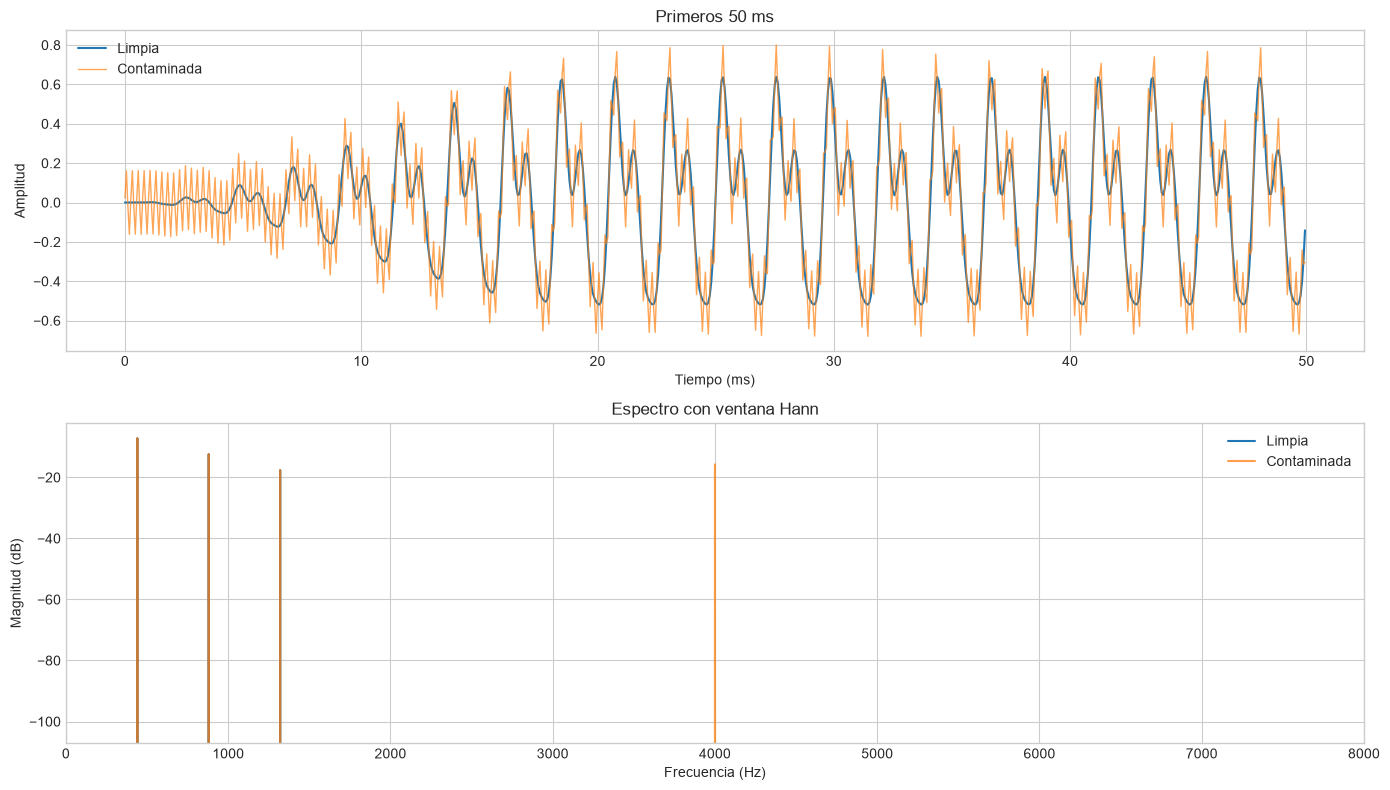

In [16]:
if FS < 2*max(FRECUENCIAS_UTILES + [FRECUENCIA_INTERFERENCIA, BANDA_RUIDO[1]]):
    raise ValueError('La configuración viola Nyquist. Aumente FS o reduzca las frecuencias.')

t = np.arange(int(FS*DURACION))/FS
clean = generar_limpia(TIPO_SENAL,t,FRECUENCIAS_UTILES,AMPLITUDES_UTILES,FASES_UTILES_GRADOS,rng)
clean = fade(clean,FS,FADE_MS)
noise_raw = generar_ruido(TIPO_RUIDO,t,FS,FRECUENCIA_INTERFERENCIA,BANDA_RUIDO,NUM_IMPULSOS,rng)
noise = escalar_ruido_para_snr(clean,noise_raw,SNR_OBJETIVO_DB)
noisy = clean + noise
[clean, noise, noisy], gain = normalizar_conjunto(clean,noise,noisy,peak=PICO_MAXIMO)
snr_real = snr_db(clean,noisy)
print(f'Muestras: {len(t):,} | SNR obtenida: {snr_real:.3f} dB | Ganancia común: {gain:.5f}')

view = min(len(t),int(.05*FS))
f1,m1 = espectro(clean,FS); f2,m2 = espectro(noisy,FS)
fig,ax = plt.subplots(2,1,figsize=(14,8))
ax[0].plot(t[:view]*1000,clean[:view],label='Limpia',lw=1.5)
ax[0].plot(t[:view]*1000,noisy[:view],label='Contaminada',alpha=.7,lw=1)
ax[0].set(xlabel='Tiempo (ms)',ylabel='Amplitud',title='Primeros 50 ms'); ax[0].legend()
ax[1].plot(f1,m1,label='Limpia'); ax[1].plot(f2,m2,label='Contaminada',alpha=.75)
ax[1].set_xlim(0,FS/2); ax[1].set_ylim(max(-120,np.max(m2)-100),np.max(m2)+5)
ax[1].set(xlabel='Frecuencia (Hz)',ylabel='Magnitud (dB)',title='Espectro con ventana Hann'); ax[1].legend()
plt.tight_layout()
if CASO is not None:
    RUTA_FIGURA = Path('resultados/figuras')/f'{CASO}_graficas.png'
    RUTA_FIGURA.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(RUTA_FIGURA, dpi=300)
plt.show()

## 5. Escucha
La referencia limpia se incluye para evaluación docente. Para la defensa puede reproducirse únicamente la señal contaminada hacia el ADC del sistema.

In [17]:
print('Referencia limpia')
display(Audio(clean,rate=FS,normalize=False))
print('Entrada contaminada para el sistema')
display(Audio(noisy,rate=FS,normalize=False))

Referencia limpia


Entrada contaminada para el sistema


## 6. Exportación
Crea archivos PCM mono de 16 bits. Todos usan la misma ganancia, por lo que las relaciones de amplitud y la SNR se conservan. El JSON permite repetir y auditar la prueba.

In [18]:
if CASO is None and CARPETA_SALIDA.exists(): shutil.rmtree(CARPETA_SALIDA)
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)
def pcm16(x): return np.int16(np.clip(x,-1,1)*32767)
wavfile.write(CARPETA_SALIDA/'01_referencia_limpia.wav',FS,pcm16(clean))
wavfile.write(CARPETA_SALIDA/'02_ruido.wav',FS,pcm16(noise))
wavfile.write(CARPETA_SALIDA/'03_entrada_contaminada.wav',FS,pcm16(noisy))
RUTA_MUESTRAS = Path('resultados/muestras')/f'{CASO}_muestras.csv' if CASO is not None else CARPETA_SALIDA/'muestras_referencia.csv'
RUTA_MUESTRAS.parent.mkdir(parents=True, exist_ok=True)
np.savetxt(RUTA_MUESTRAS,np.column_stack([t,clean,noise,noisy]),
           delimiter=',',header='tiempo_s,limpia,ruido,contaminada',comments='')
metadata = {
 'nombre_prueba':NOMBRE_PRUEBA,'modo':MODO,'semilla':int(SEMILLA),'fs_Hz':int(FS),
 'duracion_s':float(DURACION),'tipo_senal':TIPO_SENAL,'frecuencias_utiles_Hz':[float(v) for v in FRECUENCIAS_UTILES],
 'amplitudes_utiles':[float(v) for v in AMPLITUDES_UTILES],'fases_grados':[float(v) for v in FASES_UTILES_GRADOS],
 'tipo_ruido':TIPO_RUIDO,'snr_objetivo_dB':float(SNR_OBJETIVO_DB),'snr_obtenida_dB':float(snr_real),
 'frecuencia_interferencia_Hz':float(FRECUENCIA_INTERFERENCIA),'banda_ruido_Hz':[float(v) for v in BANDA_RUIDO],
 'numero_impulsos':int(NUM_IMPULSOS),'pico_maximo':float(PICO_MAXIMO),'ganancia_comun':float(gain)
}
if CASO is not None:
    # El caso queda registrado en metadatos/configuraciones.json, con la SNR y ganancia obtenidas
    configs = json.loads(RUTA_CONFIG.read_text(encoding='utf-8'))
    configs[CASO] = metadata
    RUTA_CONFIG.write_text(json.dumps(configs, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')
    print(f'WAV en: {CARPETA_SALIDA}')
    print(f'Muestras en: {RUTA_MUESTRAS} | Figura en: {RUTA_FIGURA} | Metadatos en: {RUTA_CONFIG} [{CASO}]')
else:
    with open(CARPETA_SALIDA/'metadatos_prueba.json','w',encoding='utf-8') as f: json.dump(metadata,f,indent=2,ensure_ascii=False)
    with open(CARPETA_SALIDA/'LEAME.txt','w',encoding='utf-8') as f:
        f.write('03_entrada_contaminada.wav: señal que se aplica al sistema.\n01_referencia_limpia.wav: referencia reservada para calcular métricas.\n02_ruido.wav: componente de ruido aislada.\n')
    zip_path = CARPETA_SALIDA.parent/f'{NOMBRE_PRUEBA}.zip'
    if zip_path.exists(): zip_path.unlink()
    with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
        for p in CARPETA_SALIDA.iterdir(): z.write(p,arcname=p.name)
    print(f'Archivos exportados en: {CARPETA_SALIDA}')
    print(f'ZIP para descargar: {zip_path}')
display(metadata)

WAV en: pruebas/caso_1
Muestras en: resultados/muestras/caso_1_muestras.csv | Figura en: resultados/figuras/caso_1_graficas.png | Metadatos en: metadatos/configuraciones.json [caso_1]


{'nombre_prueba': 'Caso_1',
 'modo': 'manual',
 'semilla': 1000,
 'fs_Hz': 16000,
 'duracion_s': 6.0,
 'tipo_senal': 'multitono',
 'frecuencias_utiles_Hz': [440.0, 880.0, 1320.0],
 'amplitudes_utiles': [1.0, 0.55, 0.3],
 'fases_grados': [0.0, 35.0, -50.0],
 'tipo_ruido': 'tonal',
 'snr_objetivo_dB': 10.0,
 'snr_obtenida_dB': 10.000000000000014,
 'frecuencia_interferencia_Hz': 4000.0,
 'banda_ruido_Hz': [2500.0, 3800.0],
 'numero_impulsos': 10,
 'pico_maximo': 0.8,
 'ganancia_comun': 0.43780093422539856}

## 7. Filtro temporal FIR
Diseño de un filtro temporal que reduce el ruido de los casos generados arriba. Esta parte no depende del `CASO` configurado: carga los tres casos desde `resultados/muestras/` y sus parámetros desde `metadatos/configuraciones.json`, así que primero deben generarse los tres casos. El código está en `src/filtros_temporales.py` y las pruebas en `tests/`. Lo propio del filtro (tablas y señales filtradas) se guarda en `resultados/filtro_temporal/`, las figuras en `resultados/figuras/` y las métricas en `resultados/metricas.csv`.

In [1]:
import sys, csv, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

RAIZ = Path.cwd()
if not (RAIZ/'metadatos'/'configuraciones.json').exists():
    raise FileNotFoundError('Ejecute el notebook con tarea1_grupo1/ como directorio de trabajo.')
sys.path.insert(0, str(RAIZ/'src'))
import filtros_temporales as ft

DIR_PRUEBAS, DIR_RESULTADOS = RAIZ/'pruebas', RAIZ/'resultados'
DIR_FIGURAS, DIR_FIR = DIR_RESULTADOS/'figuras', DIR_RESULTADOS/'filtro_temporal'
DIR_SALIDAS = DIR_FIR/'salidas'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True); DIR_SALIDAS.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'savefig.dpi': 150, 'savefig.bbox': 'tight'})

def guardar_csv(ruta, filas):
    # Escribe una lista de diccionarios como CSV
    with open(ruta, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=list(filas[0].keys()))
        w.writeheader(); w.writerows(filas)

with open(RAIZ/'metadatos'/'configuraciones.json', encoding='utf-8') as f:
    CASOS = [dict(id=k, **v) for k, v in json.load(f).items()]
casos = {cfg['id']: ft.cargar_caso(RAIZ, cfg['id']) for cfg in CASOS}
for cfg in CASOS:
    c = casos[cfg['id']]
    print(f"{cfg['id']}: {len(c['t'])} muestras a {cfg['fs_Hz']} Hz | SNR de entrada "
          f"{ft.snr_db(c['clean'], c['noisy']):.3f} dB | ruido {cfg['tipo_ruido']}")

caso_1: 96000 muestras a 16000 Hz | SNR de entrada 10.000 dB | ruido tonal
caso_2: 96000 muestras a 16000 Hz | SNR de entrada 5.000 dB | ruido banda
caso_3: 96000 muestras a 16000 Hz | SNR de entrada 0.000 dB | ruido banda


## 8. Especificación del filtro
Se diseña para el caso 2 y se aplica a los tres. La señal útil está por debajo de 1320 Hz y el ruido de los casos 1 y 2 por encima de 2.5 kHz, así que basta un pasa bajas: banda de paso hasta 1600 Hz, banda de rechazo desde 2400 Hz (corte en 2000 Hz), rizado máximo de 0.1 dB y atenuación mínima de 60 dB. La tabla muestra qué parte de la energía del ruido cae en cada banda.

In [2]:
FS = 16_000
F_PASO, F_RECHAZO = 1600.0, 2400.0
RIZADO_MAX_DB, ATENUACION_MIN_DB = 0.1, 60.0
CASO_DISENO = 'caso_2'

print('Distribución de la energía del ruido respecto a las bandas del filtro:')
print(f"{'caso':7} {'paso 0-1600 Hz':>15} {'transición':>11} {'rechazo ≥2400 Hz':>17}")
for cfg in CASOS:
    r = casos[cfg['id']]['noise']; E = np.sum(r**2)
    pct = [100*ft.energia_en_banda(r, FS, lo, hi)/E for lo, hi in [(0, F_PASO), (F_PASO, F_RECHAZO), (F_RECHAZO, FS/2)]]
    print(f"{cfg['id']:7} {pct[0]:14.4f}% {pct[1]:10.4f}% {pct[2]:16.4f}%")

Distribución de la energía del ruido respecto a las bandas del filtro:
caso     paso 0-1600 Hz  transición  rechazo ≥2400 Hz
caso_1          0.0000%     0.0000%         100.0000%
caso_2          0.0002%     0.0337%          99.9663%
caso_3         99.9052%     0.0957%           0.0002%


## 9. Tipo y orden del filtro
Un FIR calcula cada salida solo con las entradas recientes. Un IIR reutiliza también sus salidas anteriores (realimentación): logra el mismo filtrado con menos operaciones, pero retrasa distinto cada frecuencia y, por la realimentación, puede volverse inestable. Para decidir con datos y no solo con esa teoría, se compara un FIR con ventana de Kaiser contra tres IIR (Butterworth, Chebyshev I y elíptico) que cumplen la misma especificación de magnitud. Los IIR no se implementan como solución: se diseñan con scipy solo para medir qué SNR darían en el caso 2. Se prueban los tres métodos clásicos de IIR para mostrar que la desventaja es de toda la familia y no de un diseño en particular; del lado FIR basta uno, porque todo FIR con coeficientes simétricos tiene retardo constante por construcción. El orden del FIR sale de la fórmula de Kaiser, $N \approx (A-8)/(2.285\,\Delta\omega)+1$, y se redondea a impar para que su retardo sea un número entero de muestras.

In [3]:
b_fir, beta = ft.disenar_fir_kaiser(F_PASO, F_RECHAZO, ATENUACION_MIN_DB, FS)
N_COEF = len(b_fir)
RETARDO = (N_COEF - 1)//2

def snr_mejor_retardo(s, y, max_retardo=120):
    # SNR de la salida alineada con el retardo entero que la maximiza
    return max((ft.snr_db(s[:len(s) - d], y[d:]), d) for d in range(max_retardo))

s2, x2 = casos[CASO_DISENO]['clean'], casos[CASO_DISENO]['noisy']
f_gd = np.array(CASOS[1]['frecuencias_utiles_Hz'])     # retardo de grupo en los tonos útiles
comparacion = []
disenos_iir = {
    'Butterworth': signal.buttord(F_PASO, F_RECHAZO, RIZADO_MAX_DB, ATENUACION_MIN_DB, fs=FS),
    'Chebyshev I': signal.cheb1ord(F_PASO, F_RECHAZO, RIZADO_MAX_DB, ATENUACION_MIN_DB, fs=FS),
    'Elíptico': signal.ellipord(F_PASO, F_RECHAZO, RIZADO_MAX_DB, ATENUACION_MIN_DB, fs=FS),
}
filtros_iir = {}
for nombre, (orden, wn) in disenos_iir.items():
    if nombre == 'Butterworth':
        sos = signal.butter(orden, wn, fs=FS, output='sos')
    elif nombre == 'Chebyshev I':
        sos = signal.cheby1(orden, RIZADO_MAX_DB, wn, fs=FS, output='sos')
    else:
        sos = signal.ellip(orden, RIZADO_MAX_DB, ATENUACION_MIN_DB, wn, fs=FS, output='sos')
    filtros_iir[nombre] = sos
    b_i, a_i = signal.sos2tf(sos)
    gd = signal.group_delay((b_i, a_i), w=f_gd, fs=FS)[1]
    snr_out, d = snr_mejor_retardo(s2, signal.sosfilt(sos, x2))
    comparacion.append({'filtro': f'IIR {nombre}', 'orden': orden, 'mac_por_muestra': 5*int(np.ceil(orden/2)),
                        'coeficientes': 5*int(np.ceil(orden/2)), 'retardo_grupo_muestras': f'{gd.min():.1f} – {gd.max():.1f}',
                        'snr_salida_caso2_dB': snr_out})

snr_fir, _ = snr_mejor_retardo(s2, signal.lfilter(b_fir, 1, x2))
comparacion.insert(0, {'filtro': 'FIR Kaiser', 'orden': N_COEF - 1, 'mac_por_muestra': N_COEF,
                       'coeficientes': N_COEF, 'retardo_grupo_muestras': f'{RETARDO} (constante)',
                       'snr_salida_caso2_dB': snr_fir})

print(f'FIR Kaiser: {N_COEF} coeficientes (orden {N_COEF-1}), beta = {beta:.3f}, retardo = {RETARDO} muestras '
      f'= {1000*RETARDO/FS:.3f} ms\n')
print(f"{'filtro':16} {'orden':>5} {'MAC/muestra':>11} {'retardo de grupo en tonos útiles':>33} {'SNR salida caso 2':>18}")
for r in comparacion:
    print(f"{r['filtro']:16} {r['orden']:5d} {r['mac_por_muestra']:11d} {r['retardo_grupo_muestras']:>33} "
          f"{r['snr_salida_caso2_dB']:15.2f} dB")
guardar_csv(DIR_FIR/'comparacion_tipos_filtro.csv', comparacion)

FIR Kaiser: 75 coeficientes (orden 74), beta = 5.653, retardo = 37 muestras = 2.312 ms

filtro           orden MAC/muestra  retardo de grupo en tonos útiles  SNR salida caso 2
FIR Kaiser          74          75                    37 (constante)           65.14 dB
IIR Butterworth     20          50                       18.4 – 24.7           15.46 dB
IIR Chebyshev I     10          25                       13.3 – 20.6           14.84 dB
IIR Elíptico         6          15                        6.0 – 10.6           18.64 dB


Se elige el FIR. Con la misma magnitud, los IIR dejan mucha menos SNR porque retrasan distinto cada tono útil y deforman la señal. El FIR retrasa todo por igual (37 muestras, 2.3 ms) y siempre es estable. A cambio cuesta más operaciones: 75 por muestra contra 15 del elíptico.

## 10. Coeficientes y función de transferencia
El filtro se aplica con la ecuación de diferencias $y[n] = \sum_{k=0}^{74} b_k\,x[n-k]$: cada salida es una suma ponderada de las últimas 75 entradas, sin realimentación. Su función de transferencia es $H(z) = \sum_{k=0}^{74} b_k z^{-k} = (b_0 z^{74} + \cdots + b_{74})/z^{74}$. Los coeficientes son simétricos, que es lo que da la fase lineal; la tabla completa queda en `resultados/filtro_temporal/coeficientes_fir.csv`.

In [4]:
print(f'Simétricos: {np.allclose(b_fir, b_fir[::-1])} | suma (ganancia en DC) = {b_fir.sum():.6f}\n')
print(f"{'k':>3} {'b_k':>14}     {'k':>3} {'b_k':>14}")
mitad = (N_COEF + 1)//2
for i in range(mitad):
    izq = f'{i:3d} {b_fir[i]:14.8f}'
    j = i + mitad
    der = f'{j:3d} {b_fir[j]:14.8f}' if j < N_COEF else ''
    print(f'{izq}     {der}')
guardar_csv(DIR_FIR/'coeficientes_fir.csv', [{'k': k, 'b_k': f'{v:.17g}'} for k, v in enumerate(b_fir)])

Simétricos: True | suma (ganancia en DC) = 1.000000

  k            b_k       k            b_k
  0    -0.00012399      38     0.22458918
  1     0.00000000      39     0.15791848
  2     0.00026665      40     0.07374851
  3     0.00051276      41     0.00000000
  4     0.00047769      42    -0.04293630
  5    -0.00000000      43    -0.04955937
  6    -0.00077473      44    -0.02930531
  7    -0.00136002      45    -0.00000000
  8    -0.00117788      46     0.02143970
  9     0.00000000      47     0.02630595
 10     0.00171009      48     0.01623398
 11     0.00287475      49     0.00000000
 12     0.00239807      50    -0.01249877
 13    -0.00000000      51    -0.01555298
 14    -0.00327370      52    -0.00968177
 15    -0.00536534      53    -0.00000000
 16    -0.00437661      54     0.00749148
 17     0.00000000      55     0.00929924
 18     0.00575858      56     0.00575858
 19     0.00929924      57     0.00000000
 20     0.00749148      58    -0.00437661
 21    -0.00000000     

In [5]:
terminos = ' + '.join(f'({b_fir[k]:.6f}) z^-{k}' if k else f'({b_fir[k]:.6f})' for k in range(4))
centro = f'({b_fir[RETARDO]:.6f}) z^-{RETARDO}'
print(f'H(z) = {terminos} + ... + {centro} + ... + ({b_fir[-1]:.6f}) z^-{N_COEF-1}')

H(z) = (-0.000124) + (0.000000) z^-1 + (0.000267) z^-2 + (0.000513) z^-3 + ... + (0.249923) z^-37 + ... + (-0.000124) z^-74


## 11. Polos, ceros y estabilidad
Los 74 polos están en $z = 0$, así que la región de convergencia del filtro causal es $|z| > 0$. Incluye el círculo unitario, por lo que el filtro es estable. Los ceros sobre el círculo son las frecuencias que el filtro anula. Como comparación se dibuja el IIR elíptico de la sección 9, que no se usa como solución: sus polos quedan cerca del círculo unitario, con mucho menos margen de estabilidad que el FIR.

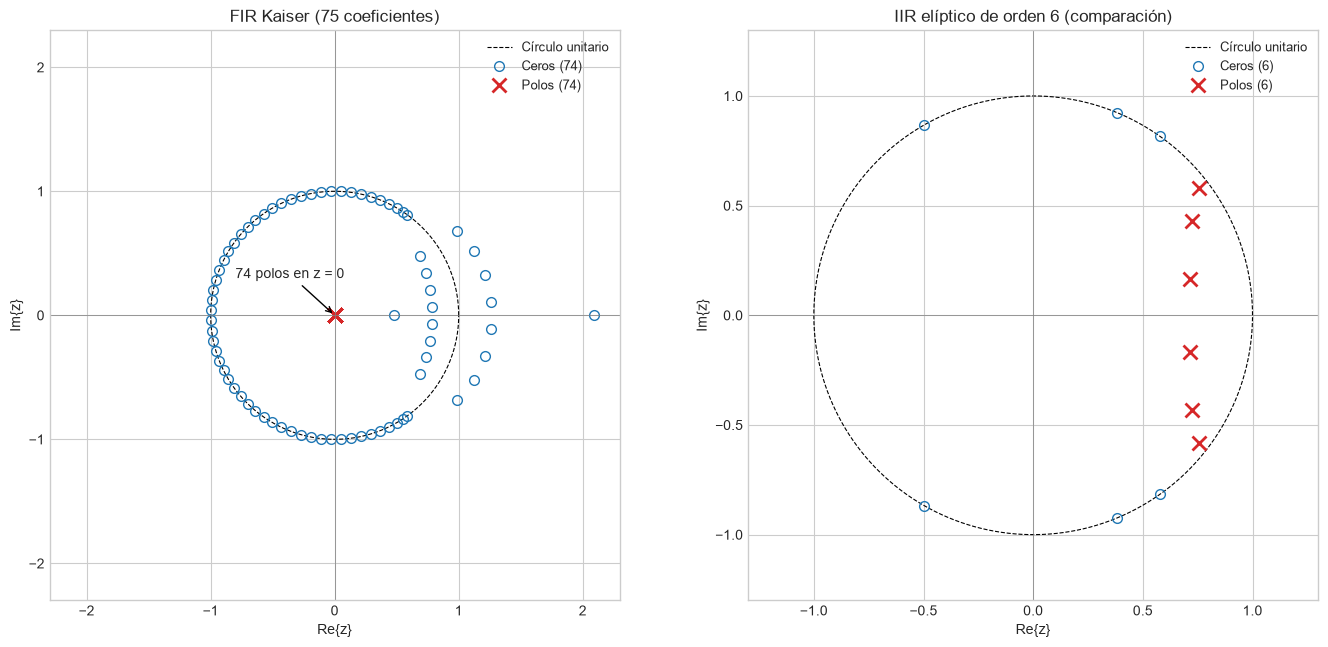

FIR: 74 ceros (56 sobre el círculo unitario), 74 polos en z = 0
     max |polo| = 0.000 < 1 -> estable: True | ROC causal: |z| > 0 | sum|h[n]| = 1.7039
Elíptico: max |polo| = 0.9529 -> estable: True


In [6]:
ceros, polos = ft.polos_ceros(b_fir)
b_e, a_e = signal.sos2tf(filtros_iir['Elíptico'])
ceros_e, polos_e = ft.polos_ceros(b_e, a_e)

fig, axs = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, z, p, titulo in [(axs[0], ceros, polos, f'FIR Kaiser ({N_COEF} coeficientes)'),
                         (axs[1], ceros_e, polos_e, 'IIR elíptico de orden 6 (comparación)')]:
    th = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(th), np.sin(th), 'k--', lw=.8, label='Círculo unitario')
    ax.plot(z.real, z.imag, 'o', mfc='none', ms=7, label=f'Ceros ({len(z)})')
    ax.plot(p.real, p.imag, 'x', ms=10, mew=2, color='C3', label=f'Polos ({len(p)})')
    ax.axhline(0, color='gray', lw=.5); ax.axvline(0, color='gray', lw=.5)
    lim = max(1.3, 1.1*np.max(np.abs(np.concatenate([z, p]))))
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect='equal', xlabel='Re{z}', ylabel='Im{z}', title=titulo)
    ax.legend(loc='upper right', fontsize=9)
axs[0].annotate(f'{len(polos)} polos en z = 0', (0, 0), xytext=(-0.8, 0.3), arrowprops={'arrowstyle': '->'})
fig.tight_layout(); fig.savefig(DIR_FIGURAS/'fir_polos_ceros.png'); plt.show()

sobre_circulo = np.sum(np.abs(np.abs(ceros) - 1) < 1e-6)
print(f'FIR: {len(ceros)} ceros ({sobre_circulo} sobre el círculo unitario), {len(polos)} polos en z = 0')
print(f'     max |polo| = {np.max(np.abs(polos)):.3f} < 1 -> estable: {ft.es_estable(polos)} | '
      f'ROC causal: |z| > 0 | sum|h[n]| = {np.abs(b_fir).sum():.4f}')
print(f'Elíptico: max |polo| = {np.max(np.abs(polos_e)):.4f} -> estable: {ft.es_estable(polos_e)}')

## 12. Respuesta en magnitud, fase y retardo de grupo

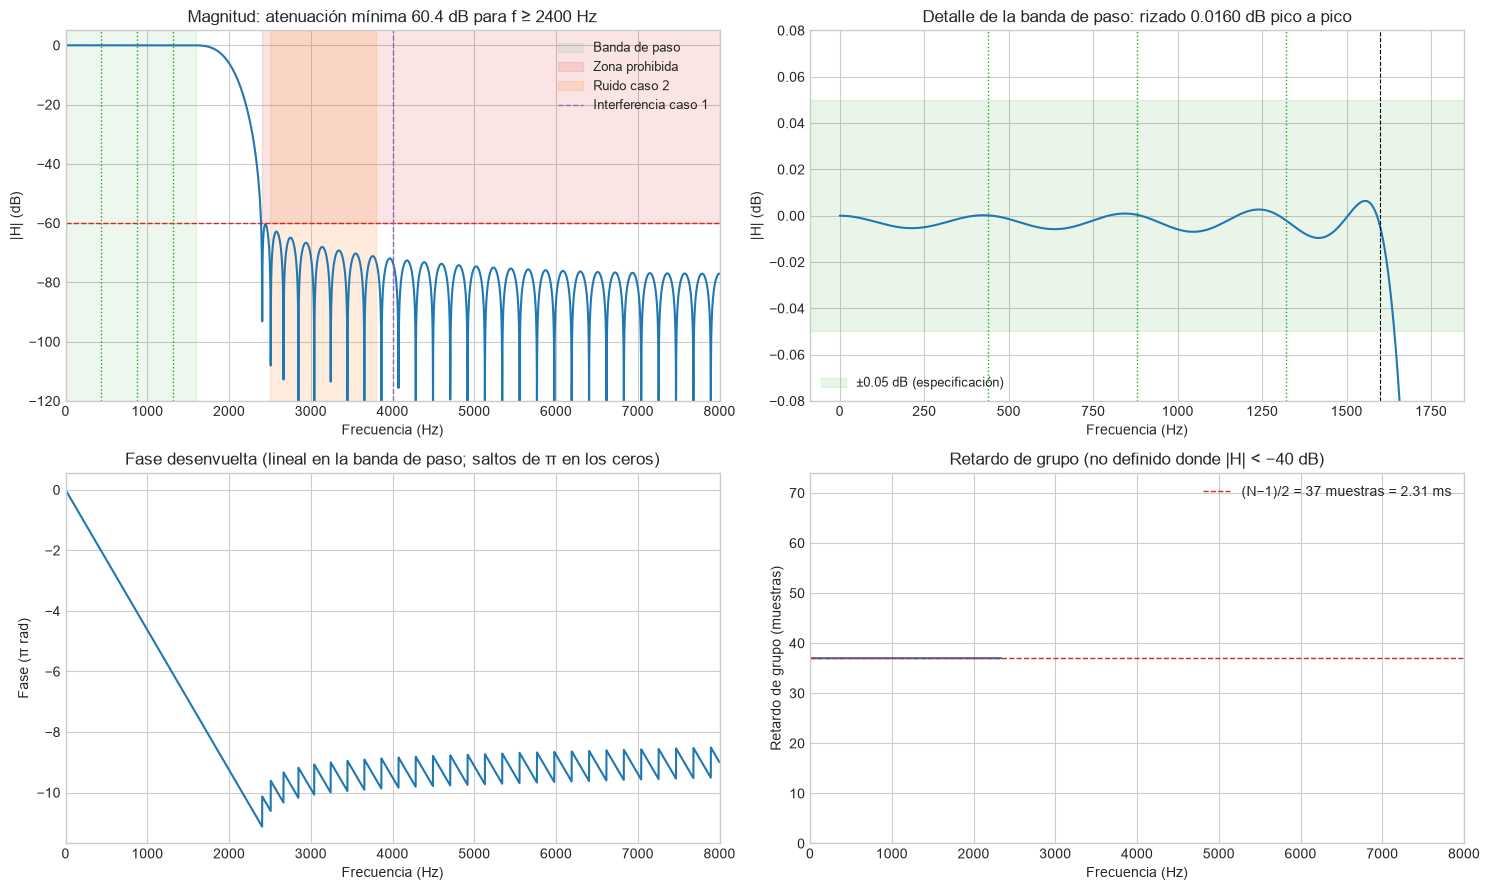

Rizado medido: 0.0160 dB (≤ 0.1) | Atenuación medida: 60.39 dB (≥ 60) -> cumple especificación: True
Retardo de grupo en la banda de paso: 37.000000 – 37.000000 muestras


In [7]:
f, H, mag_db, fase, gd = ft.respuesta_frecuencia(b_fir, 1.0, FS)
rizado, atenuacion = ft.medir_especificacion(b_fir, 1.0, FS, F_PASO, F_RECHAZO)

fig, axs = plt.subplots(2, 2, figsize=(15, 9))
ax = axs[0, 0]
ax.plot(f, mag_db)
ax.axvspan(0, F_PASO, color='C2', alpha=.08, label='Banda de paso')
ax.fill_between([F_RECHAZO, FS/2], -ATENUACION_MIN_DB, 10, color='C3', alpha=.12, label='Zona prohibida')
ax.axhline(-ATENUACION_MIN_DB, color='C3', ls='--', lw=1)
for fu in CASOS[0]['frecuencias_utiles_Hz']: ax.axvline(fu, color='C2', ls=':', lw=1)
ax.axvspan(*CASOS[1]['banda_ruido_Hz'], color='C1', alpha=.15, label='Ruido caso 2')
ax.axvline(CASOS[0]['frecuencia_interferencia_Hz'], color='C4', ls='--', lw=1, label='Interferencia caso 1')
ax.set(xlim=(0, FS/2), ylim=(-120, 5), xlabel='Frecuencia (Hz)', ylabel='|H| (dB)',
       title=f'Magnitud: atenuación mínima {atenuacion:.1f} dB para f ≥ {F_RECHAZO:.0f} Hz')
ax.legend(loc='upper right', fontsize=9)

ax = axs[0, 1]
sel = f <= F_PASO*1.1
ax.plot(f[sel], mag_db[sel])
ax.axhspan(-RIZADO_MAX_DB/2, RIZADO_MAX_DB/2, color='C2', alpha=.1, label='±0.05 dB (especificación)')
for fu in CASOS[0]['frecuencias_utiles_Hz']: ax.axvline(fu, color='C2', ls=':', lw=1)
ax.axvline(F_PASO, color='k', ls='--', lw=.8)
ax.set(ylim=(-0.08, 0.08), xlabel='Frecuencia (Hz)', ylabel='|H| (dB)',
       title=f'Detalle de la banda de paso: rizado {rizado:.4f} dB pico a pico')
ax.legend(loc='lower left', fontsize=9)

ax = axs[1, 0]
ax.plot(f, fase/np.pi)
ax.set(xlim=(0, FS/2), xlabel='Frecuencia (Hz)', ylabel='Fase (π rad)',
       title='Fase desenvuelta (lineal en la banda de paso; saltos de π en los ceros)')

ax = axs[1, 1]
ax.plot(f, gd)
ax.axhline(RETARDO, color='C3', ls='--', lw=1, label=f'(N−1)/2 = {RETARDO} muestras = {1000*RETARDO/FS:.2f} ms')
ax.set(xlim=(0, FS/2), ylim=(0, 2*RETARDO), xlabel='Frecuencia (Hz)', ylabel='Retardo de grupo (muestras)',
       title='Retardo de grupo (no definido donde |H| < −40 dB)')
ax.legend(loc='upper right')
fig.tight_layout(); fig.savefig(DIR_FIGURAS/'fir_respuesta_frecuencia.png'); plt.show()

cumple = rizado <= RIZADO_MAX_DB and atenuacion >= ATENUACION_MIN_DB
print(f'Rizado medido: {rizado:.4f} dB (≤ {RIZADO_MAX_DB}) | Atenuación medida: {atenuacion:.2f} dB '
      f'(≥ {ATENUACION_MIN_DB:.0f}) -> cumple especificación: {cumple}')
gd_paso = gd[f <= F_PASO]
print(f'Retardo de grupo en la banda de paso: {np.nanmin(gd_paso):.6f} – {np.nanmax(gd_paso):.6f} muestras')

## 13. Verificación contra la biblioteca
La biblioteca solo se usa para obtener los coeficientes. El filtrado lo hacen dos implementaciones propias de la ecuación de diferencias: una muestra por muestra y otra por bloques de 256 muestras, como trabajará el microcontrolador. Ambas deben coincidir con `scipy.signal.lfilter` con un error máximo de $10^{-12}$; el redondeo esperado en float64 ronda $10^{-15}$. Como prueba adicional, la función muestra por muestra se verifica también con el elíptico de la comparación, para mostrar que resuelve igual de bien una ecuación de diferencias con realimentación.

In [8]:
TOLERANCIA = 1e-12
TAM_BLOQUE = 256
print(f"{'caso':7} {'implementación':36} {'max |error|':>12}  resultado")
for cfg in CASOS:
    x = casos[cfg['id']]['noisy']
    y_ref = signal.lfilter(b_fir, 1.0, x)
    for nombre, y in [('ecuacion_diferencias (FIR)', ft.ecuacion_diferencias(b_fir, [1.0], x)),
                      (f'FIRPorBloques (B = {TAM_BLOQUE})', ft.filtrar_por_bloques(b_fir, x, TAM_BLOQUE))]:
        err = np.max(np.abs(y - y_ref))
        assert err <= TOLERANCIA
        print(f"{cfg['id']:7} {nombre:36} {err:12.2e}  OK")
# La implementación general también reproduce un IIR (elíptico de la comparación)
err_iir = np.max(np.abs(ft.ecuacion_diferencias(b_e, a_e, x2) - signal.lfilter(b_e, a_e, x2)))
assert err_iir <= TOLERANCIA
print(f"{CASO_DISENO:7} {'ecuacion_diferencias (IIR elíptico)':36} {err_iir:12.2e}  OK")

caso    implementación                        max |error|  resultado


caso_1  ecuacion_diferencias (FIR)               2.22e-16  OK
caso_1  FIRPorBloques (B = 256)                  6.66e-16  OK


caso_2  ecuacion_diferencias (FIR)               1.11e-16  OK
caso_2  FIRPorBloques (B = 256)                  3.89e-16  OK
caso_3  ecuacion_diferencias (FIR)               2.22e-16  OK


caso_3  FIRPorBloques (B = 256)                  5.55e-16  OK


caso_2  ecuacion_diferencias (IIR elíptico)      1.70e-13  OK


## 14. Aplicación a los tres casos
La salida se adelanta 37 muestras para compararla con la señal limpia. Como el filtro es lineal, la señal y el ruido se filtran por separado para medir cuánto ruido se elimina y cuánto se deforma la señal útil.

In [9]:
filtro = lambda v: ft.filtrar_por_bloques(b_fir, v, TAM_BLOQUE)
metricas_fir, salidas_fir = {}, {}
for cfg in CASOS:
    c = casos[cfg['id']]
    m = ft.evaluar_filtro(c['clean'], c['noise'], filtro, RETARDO)
    salidas_fir[cfg['id']] = m.pop('salida')
    y_completa = filtro(c['noisy'])
    wavfile.write(DIR_SALIDAS/f"{cfg['id']}_salida_fir.wav", FS, ft.pcm16(y_completa))
    # tiempo por bloque: se procesa la señal completa bloque a bloque y se promedia
    fir = ft.FIRPorBloques(b_fir); bloques = [c['noisy'][i:i+TAM_BLOQUE] for i in range(0, len(c['noisy']), TAM_BLOQUE)]
    t0 = time.perf_counter()
    for blq in bloques: fir.procesar(blq)
    m['tiempo_por_bloque_us'] = 1e6*(time.perf_counter() - t0)/len(bloques)
    metricas_fir[cfg['id']] = m

print(f"{'caso':7} {'SNR in':>8} {'SNR out':>8} {'ΔSNR':>8} {'MSE':>10} {'E útil %':>9} {'SNR dist':>9} {'aten. ruido':>11} {'t/bloque':>10}")
for k, m in metricas_fir.items():
    print(f"{k:7} {m['snr_entrada_dB']:8.2f} {m['snr_salida_dB']:8.2f} {m['delta_snr_dB']:8.2f} {m['mse']:10.2e} "
          f"{m['energia_util_conservada_pct']:9.3f} {m['snr_distorsion_util_dB']:9.2f} {m['atenuacion_ruido_dB']:9.2f} dB "
          f"{m['tiempo_por_bloque_us']:7.1f} µs")

caso      SNR in  SNR out     ΔSNR        MSE  E útil %  SNR dist aten. ruido   t/bloque
caso_1     10.00    69.05    59.05   1.65e-08   100.001     84.26     59.18 dB   125.8 µs
caso_2      5.00    65.14    60.14   1.51e-08   100.001     84.26     60.19 dB   121.3 µs
caso_3      0.00     0.00     0.00   2.24e-02   100.001     84.26      0.00 dB   126.5 µs


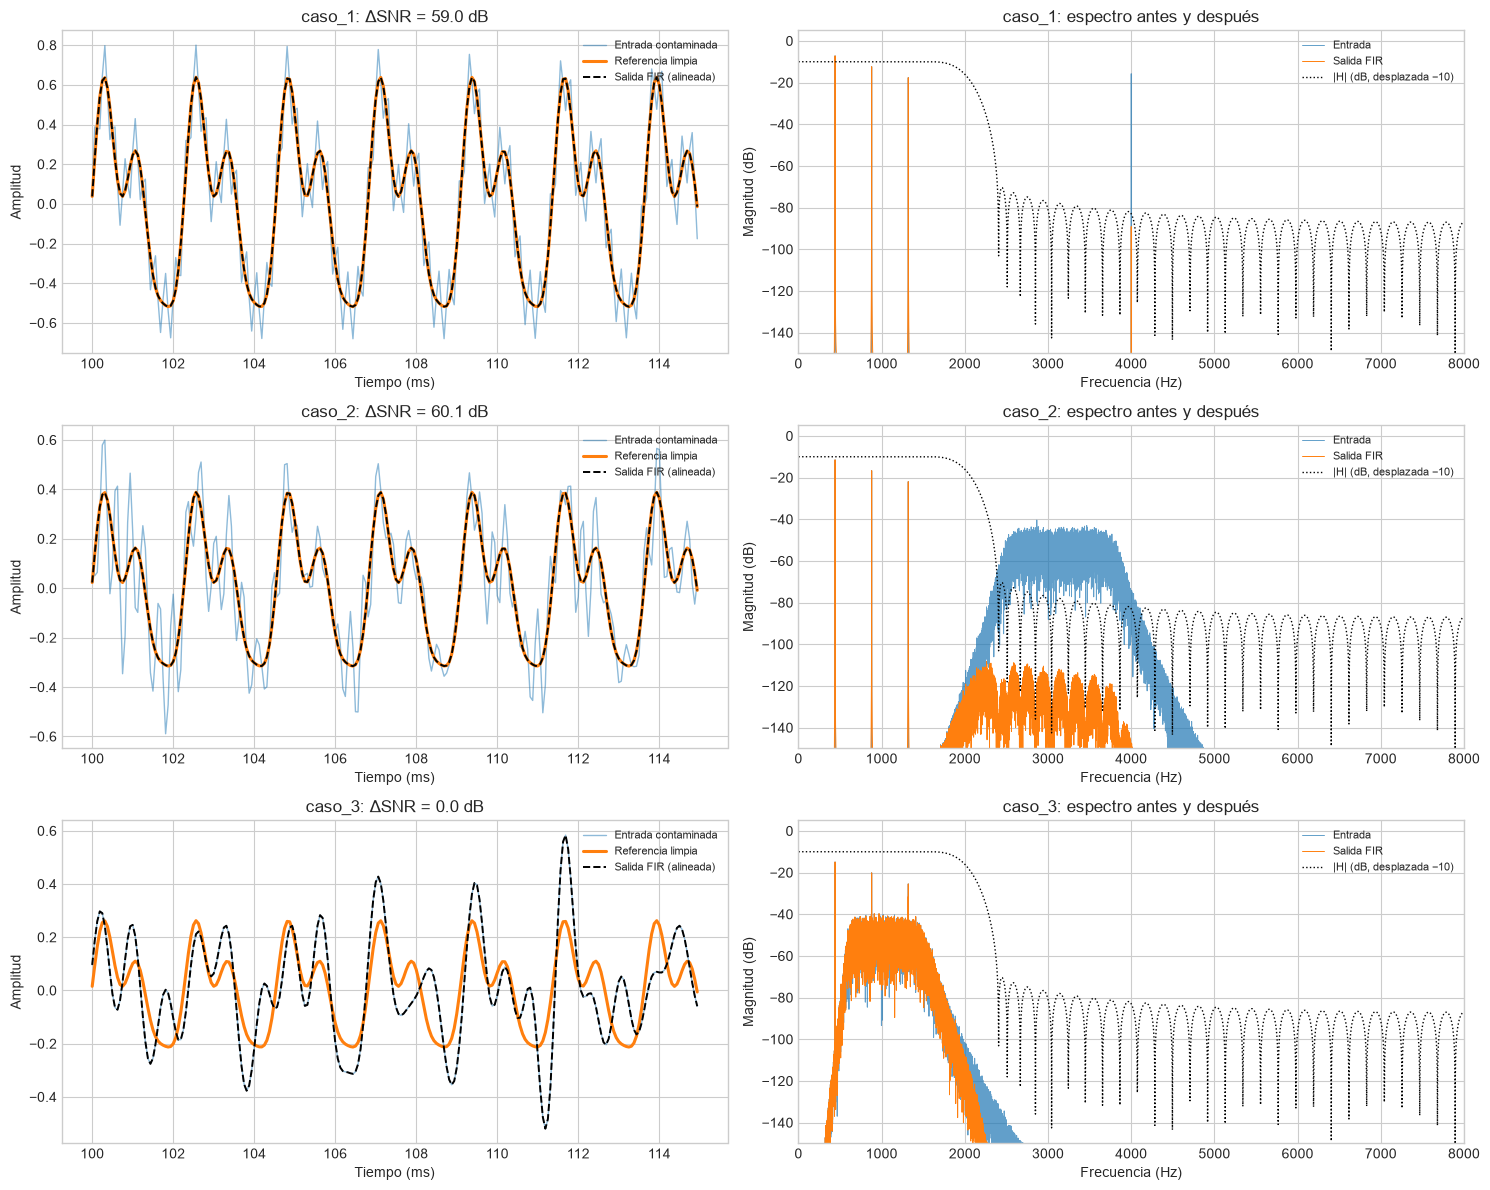

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(15, 12))
for fila, cfg in enumerate(CASOS):
    c = casos[cfg['id']]; y = salidas_fir[cfg['id']]
    i0, i1 = int(0.1*FS), int(0.115*FS)
    t_ms = c['t'][i0:i1]*1000
    ax = axs[fila, 0]
    ax.plot(t_ms, c['noisy'][i0:i1], alpha=.5, lw=1, label='Entrada contaminada')
    ax.plot(t_ms, c['clean'][i0:i1], lw=2.2, label='Referencia limpia')
    ax.plot(t_ms, y[i0:i1], '--', lw=1.4, color='k', label='Salida FIR (alineada)')
    ax.set(xlabel='Tiempo (ms)', ylabel='Amplitud',
           title=f"{cfg['id']}: ΔSNR = {metricas_fir[cfg['id']]['delta_snr_dB']:.1f} dB")
    ax.legend(loc='upper right', fontsize=8)
    ax = axs[fila, 1]
    f1, m_in = ft.espectro_db(c['noisy'], FS)
    f2, m_out = ft.espectro_db(y, FS)
    ax.plot(f1, m_in, lw=.7, alpha=.7, label='Entrada')
    ax.plot(f2, m_out, lw=.7, label='Salida FIR')
    ax.plot(f, mag_db - 10, 'k:', lw=1, label='|H| (dB, desplazada −10)')
    ax.set(xlim=(0, FS/2), ylim=(-150, 5), xlabel='Frecuencia (Hz)', ylabel='Magnitud (dB)',
           title=f"{cfg['id']}: espectro antes y después")
    ax.legend(loc='upper right', fontsize=8)
fig.tight_layout(); fig.savefig(DIR_FIGURAS/'fir_aplicacion_casos.png'); plt.show()

En los casos 1 y 2 el ruido cae en la banda de rechazo: se atenúa unos 60 dB y la señal útil sale prácticamente intacta. En el caso 3 el ruido está dentro de la banda de paso y el filtro no lo puede separar de los tonos de 880 y 1320 Hz, así que la SNR no mejora.

## 15. Exportación de métricas
`resultados/metricas.csv` guarda las métricas por caso y por método. Por ahora contiene la entrada sin filtrar y el FIR; el método espectral se agregará con las mismas columnas.

In [11]:
filas_met = []
for cfg in CASOS:
    k = cfg['id']; c = casos[k]; m = metricas_fir[k]
    snr_in = ft.snr_db(c['clean'], c['noisy'])
    filas_met.append({'caso': k, 'metodo': 'sin_filtrar', 'snr_entrada_dB': snr_in, 'snr_salida_dB': snr_in,
                      'delta_snr_dB': 0.0, 'mse': np.mean((c['clean'] - c['noisy'])**2),
                      'energia_util_conservada_pct': 100.0, 'atenuacion_ruido_dB': 0.0,
                      'snr_distorsion_util_dB': '', 'tiempo_por_bloque_us': '', 'tam_bloque': ''})
    filas_met.append({'caso': k, 'metodo': f'fir_kaiser_{N_COEF}', 'snr_entrada_dB': m['snr_entrada_dB'],
                      'snr_salida_dB': m['snr_salida_dB'], 'delta_snr_dB': m['delta_snr_dB'], 'mse': m['mse'],
                      'energia_util_conservada_pct': m['energia_util_conservada_pct'],
                      'atenuacion_ruido_dB': m['atenuacion_ruido_dB'],
                      'snr_distorsion_util_dB': m['snr_distorsion_util_dB'],
                      'tiempo_por_bloque_us': m['tiempo_por_bloque_us'], 'tam_bloque': TAM_BLOQUE})
guardar_csv(DIR_RESULTADOS/'metricas.csv', filas_met)
print('Archivos generados:')
for p in sorted(DIR_RESULTADOS.rglob('*.*')):
    print('  ', p.relative_to(RAIZ))

Archivos generados:
   resultados/figuras/caso_1_graficas.png
   resultados/figuras/caso_2_graficas.png
   resultados/figuras/caso_3_graficas.png
   resultados/figuras/fir_aplicacion_casos.png
   resultados/figuras/fir_polos_ceros.png
   resultados/figuras/fir_respuesta_frecuencia.png
   resultados/filtro_temporal/coeficientes_fir.csv
   resultados/filtro_temporal/comparacion_tipos_filtro.csv
   resultados/filtro_temporal/salidas/caso_1_salida_fir.wav
   resultados/filtro_temporal/salidas/caso_2_salida_fir.wav
   resultados/filtro_temporal/salidas/caso_3_salida_fir.wav
   resultados/metricas.csv
   resultados/muestras/caso_1_muestras.csv
   resultados/muestras/caso_2_muestras.csv
   resultados/muestras/caso_3_muestras.csv


## Uso sugerido durante la defensa
1. Defina una semilla distinta por grupo y ejecute todo el notebook.
2. Conserve `01_referencia_limpia.wav` y `metadatos_prueba.json` como información docente.
3. Reproduzca `03_entrada_contaminada.wav` hacia el ADC, comenzando con volumen bajo.
4. Solicite al grupo diagnosticar el ruido, ajustar su sistema y mostrar ambas salidas.
5. Capture las salidas y compárelas contra la referencia con MSE, SNR, energía, atenuación y latencia.
6. Si desea exactamente el mismo caso otra vez, reutilice la semilla y la configuración guardada.